# MODEL TRAINING PIPELINE

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')


### Load Data

In [2]:
df = pd.read_csv('../data/processed/processed_data.csv')

### MODEL 1: REPURCHASE PREDICTION (CLASSIFICATION)

In [3]:
# Feature selection
feature_cols = [
    'Age',
    'MonthlyBudget_USD',
    'ProductEffectiveness_Score',
    'CustomerSatisfaction_pct',
    'ActiveIngredientsCount'
]

# Add encoded columns
encoded_cols = [
    col for col in df.columns
    if col.endswith('_encoded')
]

feature_cols.extend(encoded_cols)

# Add ingredient columns
ingredient_cols = [
    col for col in df.columns
    if col.startswith('Uses')
]

feature_cols.extend(ingredient_cols)

# Keep only existing columns
feature_cols = [
    col for col in feature_cols
    if col in df.columns
]

# Features and target
X = df[feature_cols]
y = df['WillRepurchase']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### RANDOM FOREST CLASSIFIER

In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

# Predictions
y_pred = rf_clf.predict(X_test)
y_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

# Classification report
class_report = classification_report(y_test, y_pred)


### FEATURE IMPORTANCE

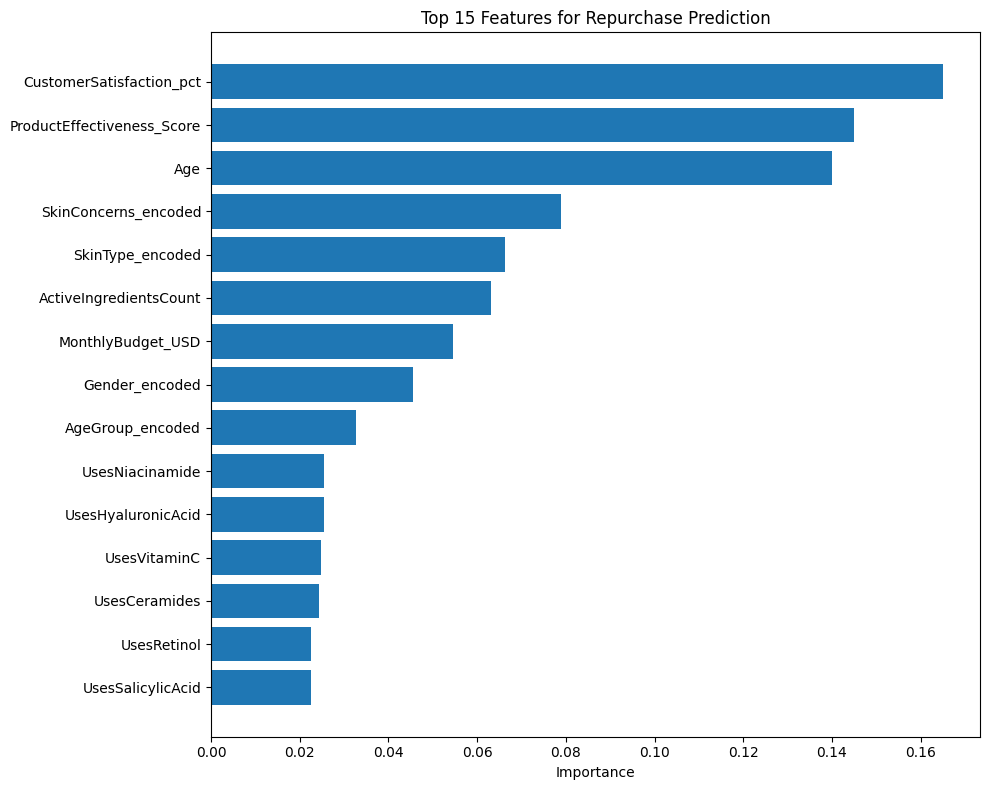

In [5]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance.head(15)['feature'],
    feature_importance.head(15)['importance']
)

plt.xlabel('Importance')
plt.title('Top 15 Features for Repurchase Prediction')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


### CONFUSION MATRIX

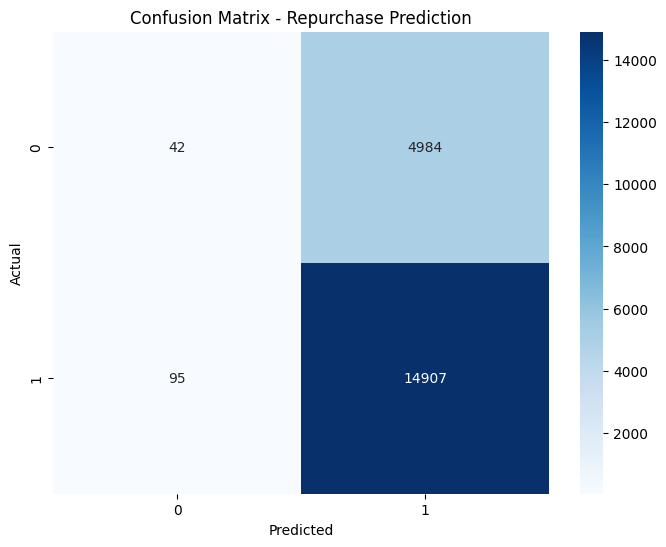

In [6]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Repurchase Prediction')

plt.show()


### MODEL 2: CUSTOMER SATISFACTION PREDICTION (REGRESSION)

In [7]:
X_reg = df[feature_cols]
y_reg = df['CustomerSatisfaction_pct']

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_reg = rf_reg.predict(X_test_reg)

# Metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test_reg, y_pred_reg)

r2 = r2_score(y_test_reg, y_pred_reg)


### ACTUAL VS PREDICTED PLOT

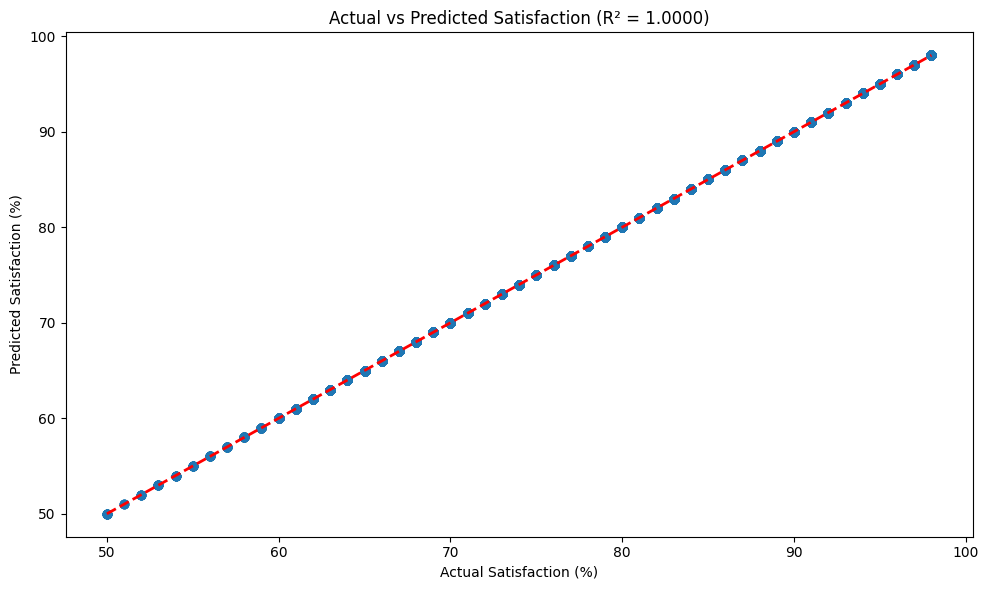

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    'r--',
    lw=2
)

plt.xlabel('Actual Satisfaction (%)')
plt.ylabel('Predicted Satisfaction (%)')

plt.title(
    f'Actual vs Predicted Satisfaction (R² = {r2:.4f})'
)

plt.tight_layout()
plt.show()


### HYPERPARAMETER TUNING

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

# 👉 FIRST fit the model
random_search.fit(X_train, y_train)

# 👉 THEN access best model
best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)

Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}


### SAVE MODELS

In [14]:
import os
import joblib

# create folder if not exists
os.makedirs('../data/models', exist_ok=True)

# save models
joblib.dump(best_model, '../data/models/recommender_model.pkl')

joblib.dump(rf_reg, '../data/models/satisfaction_regressor.pkl')

joblib.dump(feature_cols, '../data/models/feature_columns.pkl')


['../data/models/feature_columns.pkl']

### RESULTS

In [15]:
classification_results = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC-ROC'],
    'Score': [accuracy, auc]
})

regression_results = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R² Score'],
    'Score': [rmse, mae, r2]
})

display(classification_results)

display(regression_results)

display(feature_importance.head(10))

,Metric,Score
0,Accuracy,0.746405
1,AUC-ROC,0.506013


,Metric,Score
0,RMSE,0.0
1,MAE,0.0
2,R² Score,1.0


,feature,importance
3,CustomerSatisfaction_pct,0.165129
2,ProductEffectiveness_Score,0.144926
0,Age,0.139912
7,SkinConcerns_encoded,0.078958
5,SkinType_encoded,0.066182
4,ActiveIngredientsCount,0.063048
1,MonthlyBudget_USD,0.054631
6,Gender_encoded,0.045631
8,AgeGroup_encoded,0.032671
12,UsesNiacinamide,0.025459
